In [16]:
# load in libraries
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [17]:
# make the database connection 
connection = sqlite3.connect('../data/bookstore.db')

### Query 1: List the title, genre, and full author name for every book sold at a store in the Pacific region. Show each sale as its own row 

In [18]:
query1 = """
SELECT
    b.title,
    b.genre,
    a.author_first || ' ' || a.author_last AS author_name
FROM transactions t
JOIN stores s ON t.store_id = s.store_id
JOIN books b ON t.book_id = b.book_id
JOIN authors a ON b.author_id = a.author_id
WHERE s.store_region = 'Pacific'
"""

In [19]:
# execute the query
results1 = pd.read_sql_query(query1, connection)
results1

,title,genre,author_name
0,The Quiet Hours,Fiction,Ocean Vuong
1,The Quiet Hours,Fiction,Ocean Vuong
2,The Quiet Hours,Fiction,Ocean Vuong
3,The Quiet Hours Vol. 2,Fiction,Malcolm Gladwell
4,The Quiet Hours Vol. 2,Fiction,Malcolm Gladwell
...,...,...,...
1754,The Habit Code Vol. 2,Self-Help,Toni Morrison
1755,The Habit Code Vol. 2,Self-Help,Toni Morrison
1756,The Habit Code Vol. 2,Self-Help,Toni Morrison
1757,The Habit Code Vol. 2,Self-Help,Toni Morrison


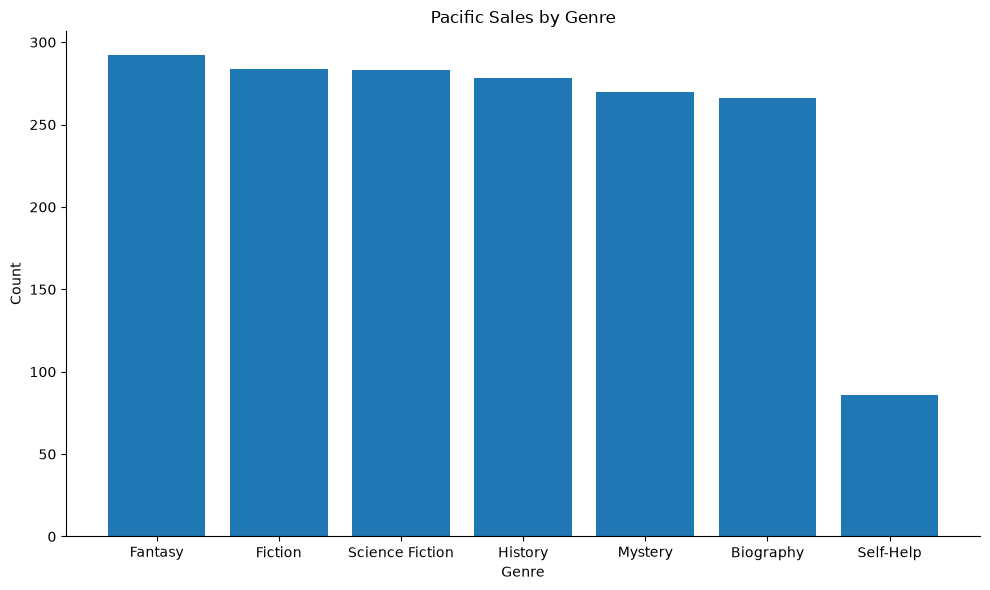

In [20]:
# create a visualization
genre_counts = results1['genre'].value_counts()

plt.figure(figsize=(10,6))
plt.bar(genre_counts.index, genre_counts.values)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Genre')
plt.ylabel('Count')
plt.title('Pacific Sales by Genre')

plt.tight_layout()
plt.show()

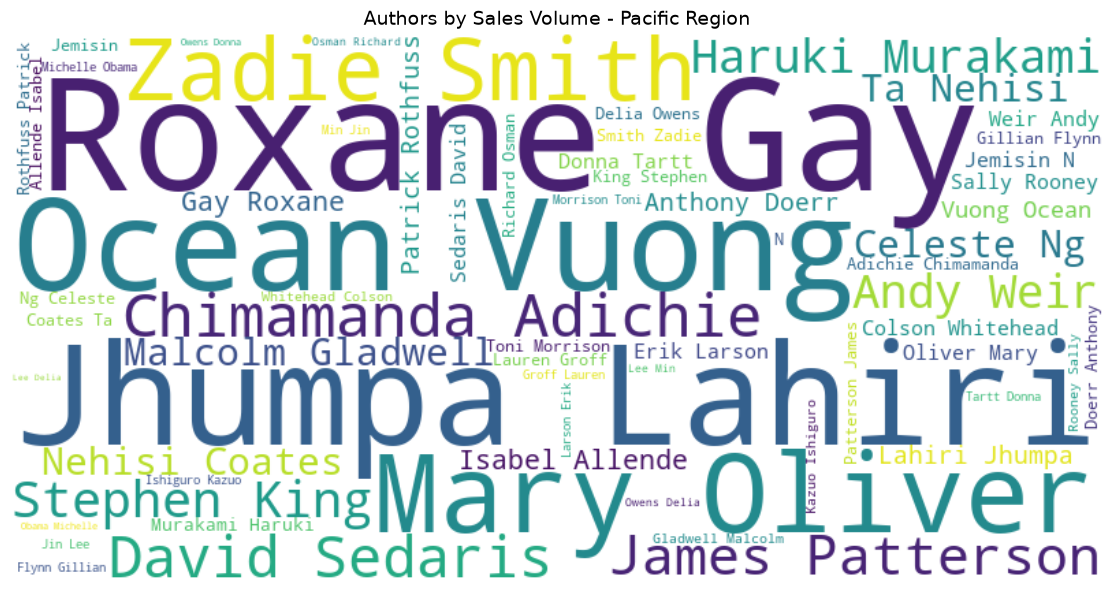

In [22]:
text = ' '.join(results1['author_name'])

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Authors by Sales Volume - Pacific Region', fontsize=14)
plt.tight_layout()
plt.show()

Discuss

### Query 2: Which genre generated the most total revenue across all transactions? Return the top 5 genres ranked by total sales, highest to lowest

In [ ]:
query2 = """ """

In [ ]:
# execute the query

In [ ]:
# create a visualization

Discuss

### Query 3: Find every member who has spent more than $200 in total across all their purchases. Return their full name, membership tier, and their total spend — but only include members who have made at least 3 separate transactions.

In [ ]:
query3 = """ """

In [ ]:
# execute the query

In [ ]:
# create a visualization

Discuss

### Query 4: For each publisher, find the single book (by title) that has generated the most total revenue. Return the publisher name, book title, and that book's total revenue.

In [ ]:
query4 = """ """

In [ ]:
# execute the query

In [ ]:
# create a visualization

Discuss

In [ ]:
connection.close()